In [2]:
import pandas as pd
df = pd.read_csv("Ride Data Responses.csv")
df.head()

,Timestamp,Your Name,Pickup Coordinate,Drop Coordinate,Fare for Bike,"[Waiting Time of Bike, No. of bikes available]",Fare for Auto,"[Waiting Time of Auto, No. of Auto Available]",Fare for Car,"[Waiting Time of Car, No. of cars available]",...,DropZone,BikeWait,BikeSupply,AutoWait,AutoSupply,CarWait,CarSupply,priceKmBike,priceKmAuto,priceKmCar
0,14-03-2026 00:00,MK,"28.6428, 77.2191","28.5000, 77.2167",175.0,"6,1",451.0,"6,1",238.0,"9,6",...,RESIDENTIAL,6,1,6,1,9,6,8.89,22.90,12.09
1,14-03-2026 00:01,MK,"28.6428, 77.2191","28.6700, 77.4200",367.0,"6,1",NaN,NaN,614.0,"5,4",...,RESIDENTIAL,6,1,0,0,5,4,12.60,0.00,21.07
2,14-03-2026 00:03,MK,"28.5695, 77.3222","28.6700, 77.4200",229.0,"3,1",380.0,"3,3",352.0,"1,4",...,RESIDENTIAL,3,1,3,3,1,4,12.25,20.33,18.83
3,14-03-2026 00:04,MK,"28.5556, 77.0952","28.6700, 77.4200",391.0,"4,1",NaN,NaN,985.0,"2,4",...,RESIDENTIAL,4,1,0,0,2,4,8.46,0.00,21.30
4,14-03-2026 00:06,MK,"28.5556, 77.0952","28.5355, 77.3910",336.0,"4,1",NaN,NaN,760.0,"2,4",...,RESIDENTIAL,4,1,0,0,2,4,8.66,0.00,19.58


In [3]:
df.columns

Index(['Timestamp', 'Your Name', 'Pickup Coordinate', 'Drop Coordinate',
       'Fare for Bike', '[Waiting Time of Bike, No. of bikes available]',
       'Fare for Auto', '[Waiting Time of Auto, No. of Auto Available]',
       'Fare for Car', '[Waiting Time of Car, No. of cars available]',
       'Platform', '  Is a Surge/High-Demand alert visible?  ', 'Hour',
       'Minute', 'DecimalHour', 'Day', 'Weekend', 'Rushhour', 'DistanceKm',
       'Duration', 'TrafficLevel', 'SurgeValue', 'PickupTemperature',
       'PickupWindSpeed', 'PickupWeatherCode', 'PickupHumidity',
       'DropTemperature', 'DropWindSpeed', 'DropWeatherCode', 'DropHumidity',
       'PickupZone', 'DropZone', 'BikeWait', 'BikeSupply', 'AutoWait',
       'AutoSupply', 'CarWait', 'CarSupply', 'priceKmBike', 'priceKmAuto',
       'priceKmCar'],
      dtype='object')

C:\Users\princ\AppData\Local\Temp\ipykernel_24288\2805198629.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


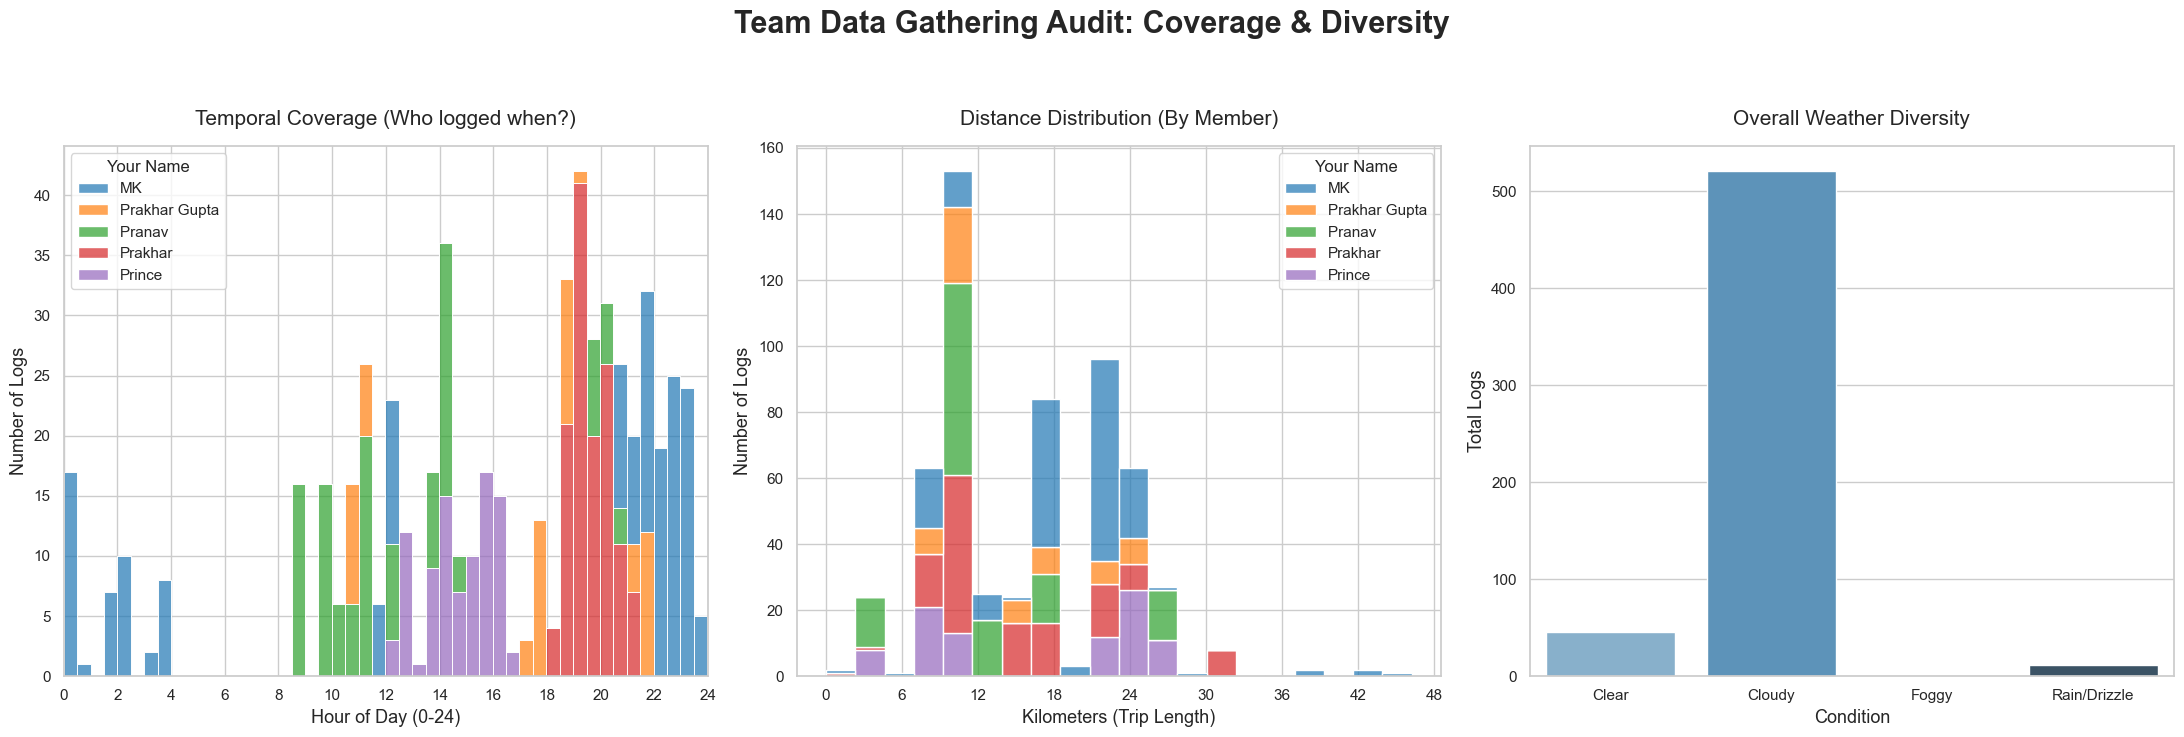

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
filename = 'Ride Data Responses.csv'
df = pd.read_csv(filename)

# Mapping Weather Codes
def map_weather(code):
    if pd.isna(code): return 'Unknown'
    if code == 0: return 'Clear'
    if code in [1, 2, 3]: return 'Cloudy'
    if code in [45, 48]: return 'Foggy'
    if code >= 51: return 'Rain/Drizzle'
    return 'Other'

df['Weather_Label'] = df['PickupWeatherCode'].apply(map_weather)
weather_order = ['Clear', 'Cloudy', 'Foggy', 'Rain/Drizzle']

# 1. Setup figure
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Team Data Gathering Audit: Coverage & Diversity', fontsize=22, fontweight='bold', y=1.05)

# --- PLOT 1: 24-HOUR TEMPORAL SPREAD (BY TEAM MEMBER) ---
sns.histplot(
    data=df, x='DecimalHour', hue='Your Name', 
    bins=48, multiple='stack', palette='tab10', ax=axes[0], alpha=0.7
)
axes[0].set_title('Temporal Coverage (Who logged when?)', fontsize=15, pad=15)
axes[0].set_xlabel('Hour of Day (0-24)', fontsize=13)
axes[0].set_ylabel('Number of Logs', fontsize=13)
axes[0].set_xticks(np.arange(0, 25, 2))
axes[0].set_xlim(0, 24)

# --- PLOT 2: DISTANCE CAPTURE SPREAD (BY TEAM MEMBER) ---
sns.histplot(
    data=df, x='DistanceKm', hue='Your Name', 
    bins=20, multiple='stack', palette='tab10', ax=axes[1], alpha=0.7
)
axes[1].set_title('Distance Distribution (By Member)', fontsize=15, pad=15)
axes[1].set_xlabel('Kilometers (Trip Length)', fontsize=13)
axes[1].set_ylabel('Number of Logs', fontsize=13)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(10))

# --- PLOT 3: WEATHER DIVERSITY ---
sns.countplot(
    data=df, x='Weather_Label', order=weather_order, 
    ax=axes[2], palette='Blues_d'
)
axes[2].set_title('Overall Weather Diversity', fontsize=15, pad=15)
axes[2].set_xlabel('Condition', fontsize=13)
axes[2].set_ylabel('Total Logs', fontsize=13)

plt.tight_layout()
plt.show()

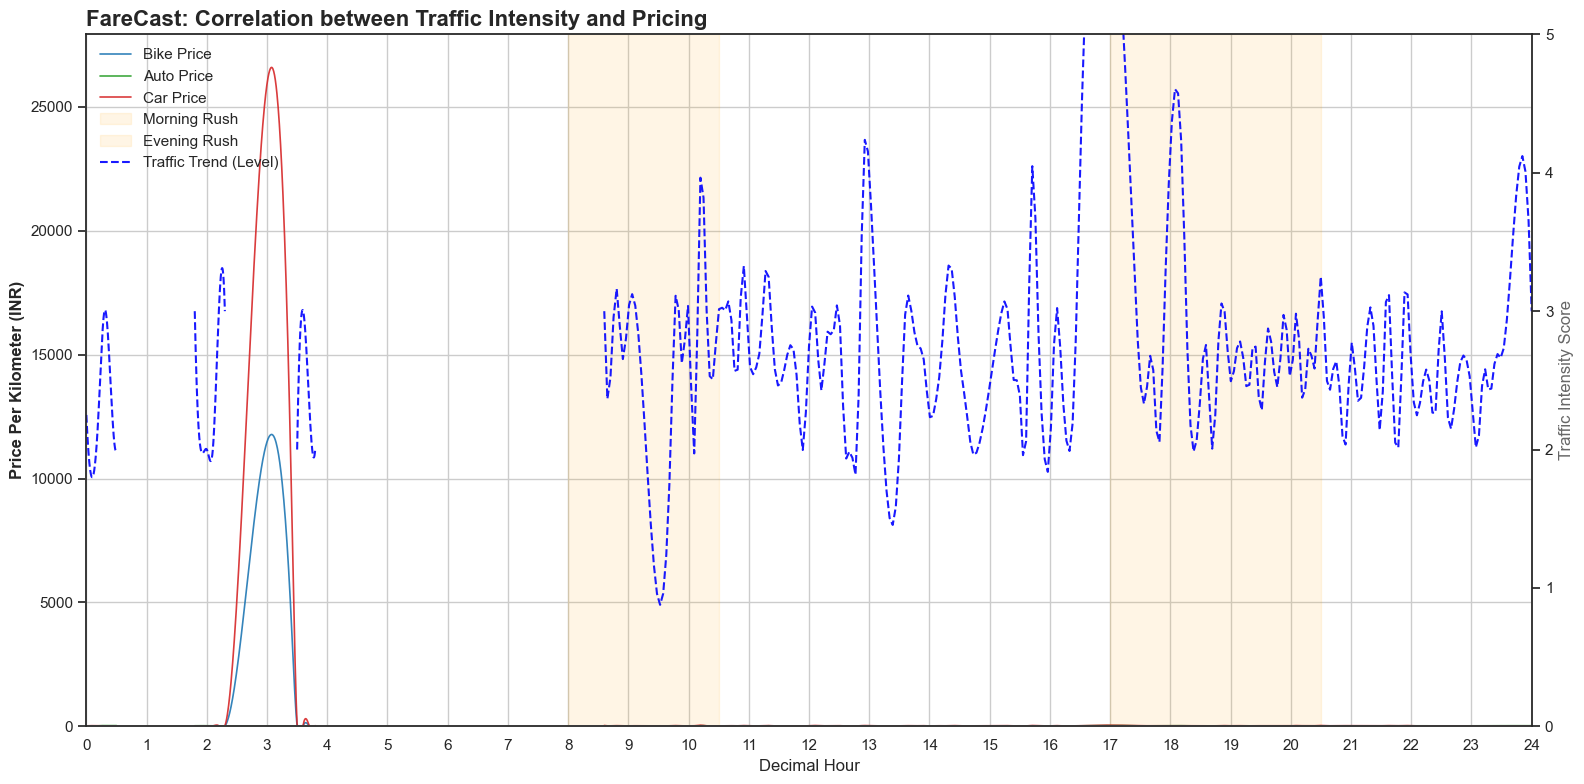

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Aggregation (Including Traffic Level)
# Mapping TrafficLevel to numeric if it's text (e.g., LOW=1, HEAVY=4)
traffic_map = {'LOW': 1, 'NORMAL': 2, 'MODERATE': 3, 'HEAVY': 4}
if df['TrafficLevel'].dtype == object:
    df['Traffic_Score'] = df['TrafficLevel'].str.upper().map(traffic_map)
else:
    df['Traffic_Score'] = df['TrafficLevel']

agg_df = df.groupby(df['DecimalHour'].round(1)).agg({
    'priceKmBike': 'mean',
    'priceKmAuto': 'mean',
    'priceKmCar': 'mean',
    'Traffic_Score': 'mean'
}).sort_index().reset_index()

def get_smooth_data(x, y):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    if len(x_c) < 4: return x_c, y_c, False
    
    x_new = np.linspace(xs.min(), xs.max(), 300) if 'xs' in locals() else np.linspace(x_c.min(), x_c.max(), 300)
    # This logic is simplified for the return; the segment logic is inside the plot loop below
    return x_c, y_c, True

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_style("white") # Cleaner background for dual-axis
ax2 = ax1.twinx() # Create the secondary axis for Traffic

def plot_dual_logic(ax, x, y, label, color, ls='-', lw=1.2, alpha=0.9, is_traffic=False):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    gaps = np.where(np.diff(x_c) > 1.2)[0] + 1
    x_segs = np.split(x_c, gaps)
    y_segs = np.split(y_c, gaps)
    
    first = True
    for xs, ys in zip(x_segs, y_segs):
        if len(xs) > 3:
            x_smooth = np.linspace(xs.min(), xs.max(), 300)
            spline = make_interp_spline(xs, ys, k=3)
            y_smooth = np.maximum(spline(x_smooth), 0)
            ax.plot(x_smooth, y_smooth, label=label if first else "", 
                    color=color, linewidth=lw, ls=ls, alpha=alpha)
        else:
            ax.plot(xs, ys, label=label if first else "", color=color, linewidth=lw, ls=ls, alpha=alpha)
        first = False

# Plot Prices on ax1 (Left Y-Axis)
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmBike'].values, 'Bike Price', '#1f77b4')
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmAuto'].values, 'Auto Price', '#2ca02c')
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmCar'].values, 'Car Price', '#d62728')

# Plot Traffic on ax2 (Right Y-Axis)
# Using a thin black dashed line for Traffic Trend
plot_dual_logic(ax2, agg_df['DecimalHour'].values, agg_df['Traffic_Score'].values, 'Traffic Trend (Level)', 'blue', ls='--', lw=1.5)

# Aesthetics
ax1.set_xlabel("Decimal Hour", fontsize=12)
ax1.set_ylabel("Price Per Kilometer (INR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Traffic Intensity Score", fontsize=12, color='black', alpha=0.6)

# Syncing Ticks
ax1.set_xticks(np.arange(0, 25, 1))
ax1.set_xlim(0, 24)
ax1.set_ylim(bottom=0)
ax2.set_ylim(0, 5) # Assuming traffic levels are 1-4

# Rush Hour Rectangles
ax1.axvspan(8, 10.5, alpha=0.1, color='orange', label='Morning Rush')
ax1.axvspan(17, 20.5, alpha=0.1, color='orange', label='Evening Rush')

plt.title("FareCast: Correlation between Traffic Intensity and Pricing", fontsize=16, fontweight='bold', loc='left')

# Integrated Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

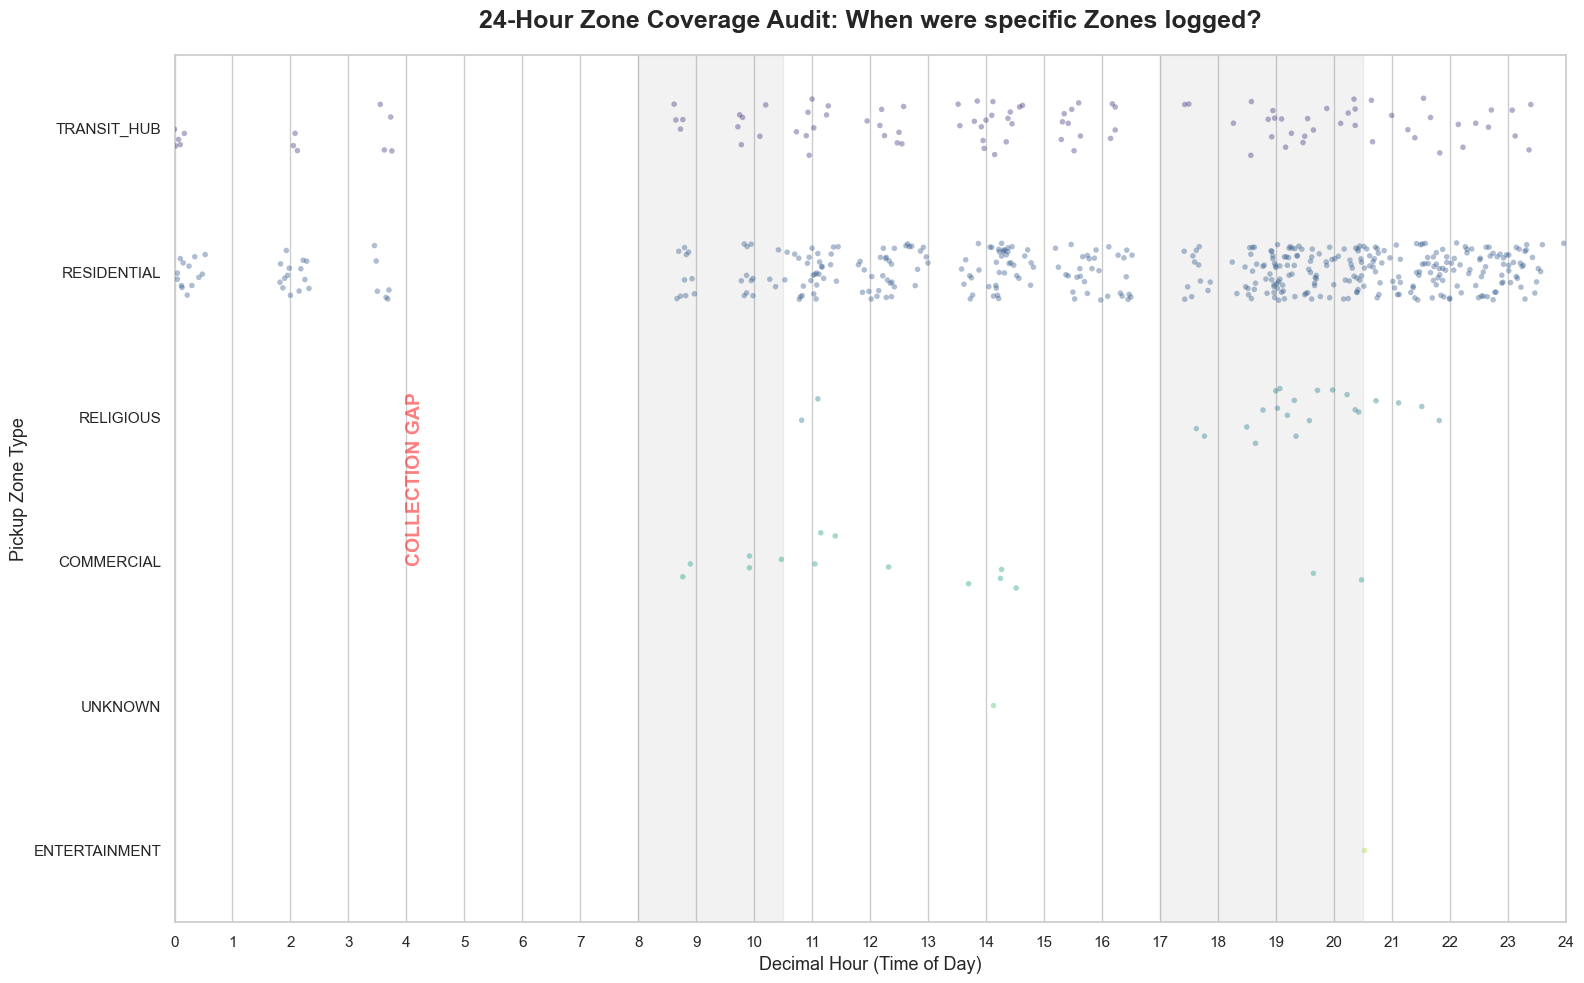

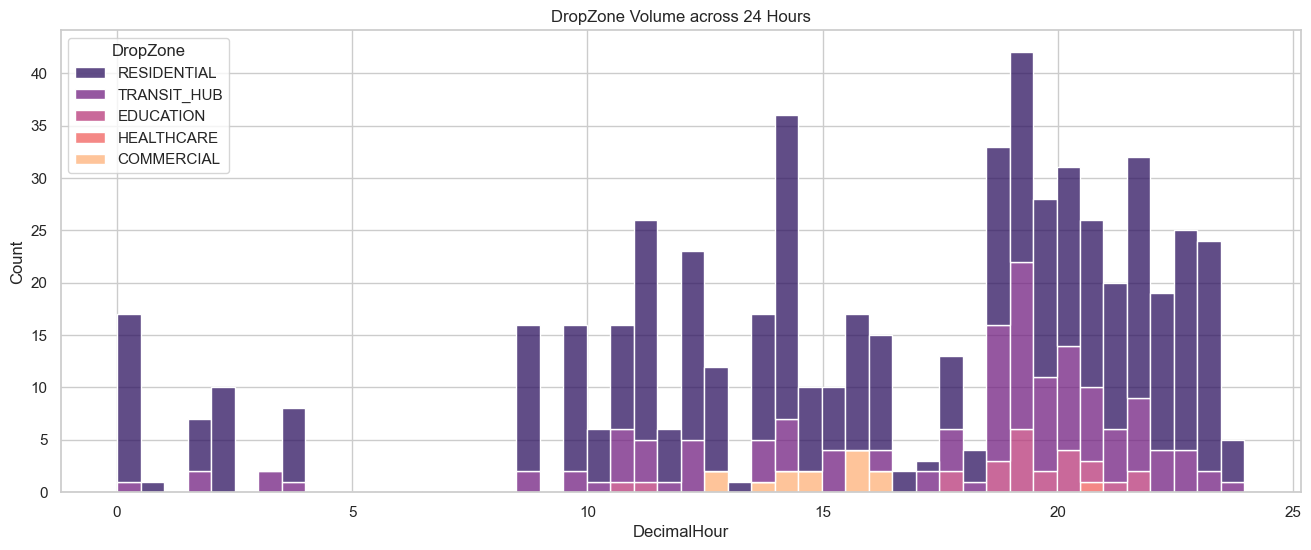

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Setup the figure
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# 3. Create a Categorical Scatter Plot (Stripplot)
# This shows every single data point as a thin dot to see the density
ax = sns.stripplot(
    data=df, 
    x='DecimalHour', 
    y='PickupZone', # Or 'PickupZone' depending on your exact CSV column name
    hue='PickupZone',
    palette='viridis',
    size=4, 
    alpha=0.4, 
    jitter=0.2,
    legend=False
)

# 4. Highlight Rush Hours to see if specific zones were ignored during peaks
plt.axvspan(8, 10.5, alpha=0.1, color='gray', label='Morning Rush')
plt.axvspan(17, 20.5, alpha=0.1, color='gray', label='Evening Rush')

# 5. Formatting
plt.xticks(np.arange(0, 25, 1))
plt.xlim(0, 24)

plt.title("24-Hour Zone Coverage Audit: When were specific Zones logged?", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Decimal Hour (Time of Day)", fontsize=13)
plt.ylabel("Pickup Zone Type", fontsize=13)

# Add a "Data Void" annotation to the most obvious gap
plt.text(4, len(df['PickupZone'].unique())/2, "COLLECTION GAP", 
         color='red', fontsize=14, fontweight='bold', rotation=90, alpha=0.5)

plt.tight_layout()
plt.show()

# --- OPTIONAL: DROPZONE SPREAD ---
# If you want to see if people are traveling TO specific zones at specific times
plt.figure(figsize=(16, 6))
sns.histplot(data=df, x='DecimalHour', hue='DropZone', multiple='stack', palette='magma', bins=48)
plt.title("DropZone Volume across 24 Hours")
plt.show()

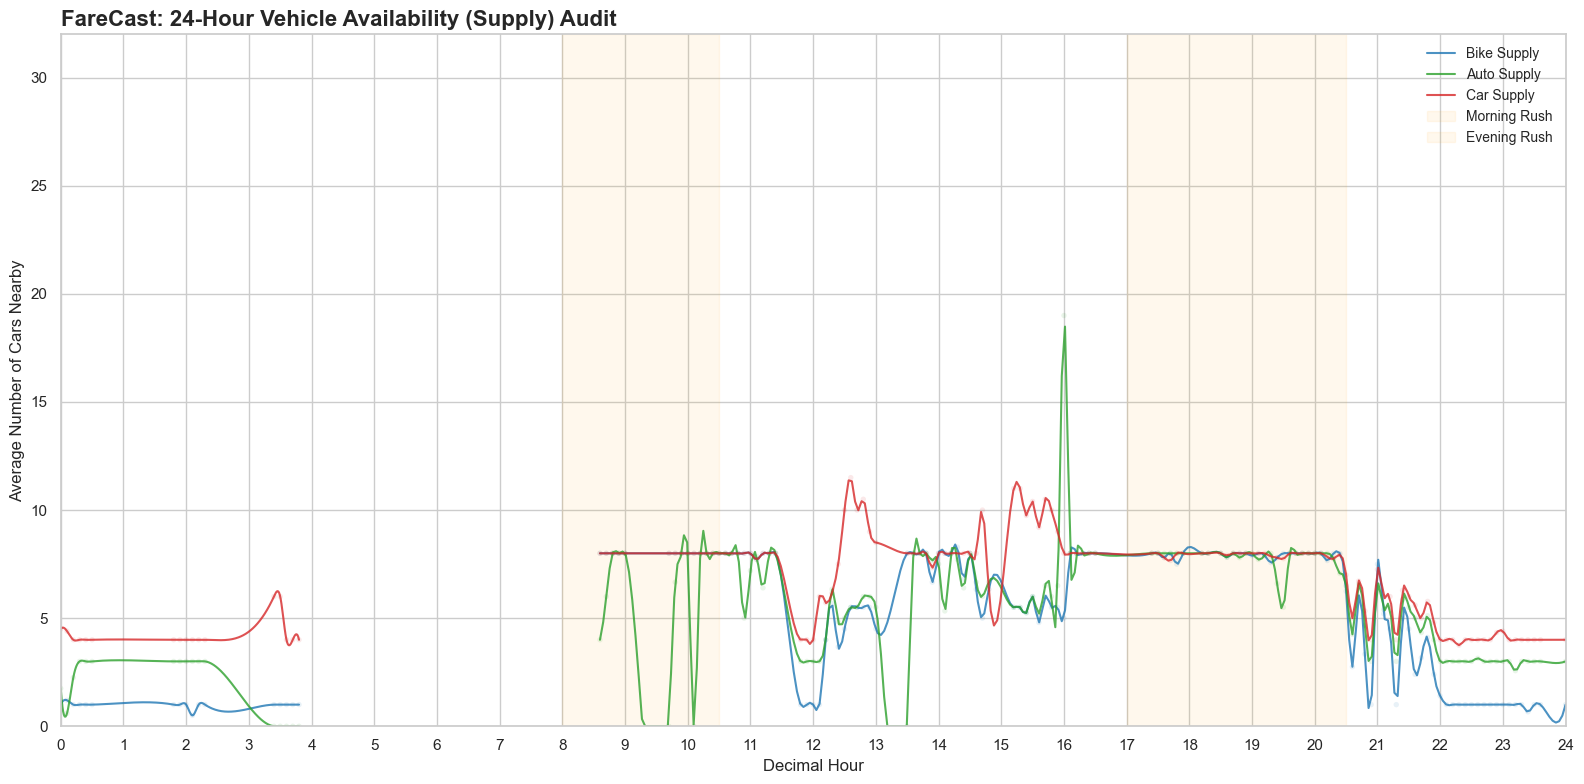

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Aggregation - Mean Supply per 0.1 hour slot
# Using your specific supply columns
for col in ['BikeSupply', 'AutoSupply', 'CarSupply']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
agg_supply = df.groupby(df['DecimalHour'].round(1)).agg({
    'BikeSupply': 'mean',
    'AutoSupply': 'mean',
    'CarSupply': 'mean'
}).sort_index().reset_index()

def plot_supply_trends(ax, x, y, label, color):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    
    if len(x_c) < 2: return

    # Scatter actual logs to show raw density
    ax.scatter(x_c, y_c, color=color, s=15, alpha=0.1, edgecolors='none')

    # Gap detection (1.5 hour threshold for supply voids)
    gaps = np.where(np.diff(x_c) > 1.5)[0] + 1
    x_segs = np.split(x_c, gaps)
    y_segs = np.split(y_c, gaps)
    
    first = True
    for xs, ys in zip(x_segs, y_segs):
        if len(xs) > 3:
            # Thin smooth spline for supply "waves"
            x_new = np.linspace(xs.min(), xs.max(), 300)
            spline = make_interp_spline(xs, ys, k=3)
            y_smooth = np.maximum(spline(x_new), 0)
            ax.plot(x_new, y_smooth, label=label if first else "", 
                    color=color, linewidth=1.5, alpha=0.8)
            first = False
        else:
            ax.plot(xs, ys, label=label if first else "", 
                    color=color, linewidth=1.5, alpha=0.6)
            first = False

# --- Visualization ---
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
ax = plt.gca()

# Plotting each supply type
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['BikeSupply'].values, 'Bike Supply', '#1f77b4')
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['AutoSupply'].values, 'Auto Supply', '#2ca02c')
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['CarSupply'].values, 'Car Supply', '#d62728')

# Overlay Rush Hours
plt.axvspan(8, 10.5, alpha=0.07, color='orange', label='Morning Rush')
plt.axvspan(17, 20.5, alpha=0.07, color='orange', label='Evening Rush')

# Formatting
plt.xticks(np.arange(0, 25, 1))
plt.xlim(0, 24)
plt.ylim(0, df[['BikeSupply', 'AutoSupply', 'CarSupply']].max().max() + 2)

plt.title("FareCast: 24-Hour Vehicle Availability (Supply) Audit", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Decimal Hour", fontsize=12)
plt.ylabel("Average Number of Cars Nearby", fontsize=12)

# Legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

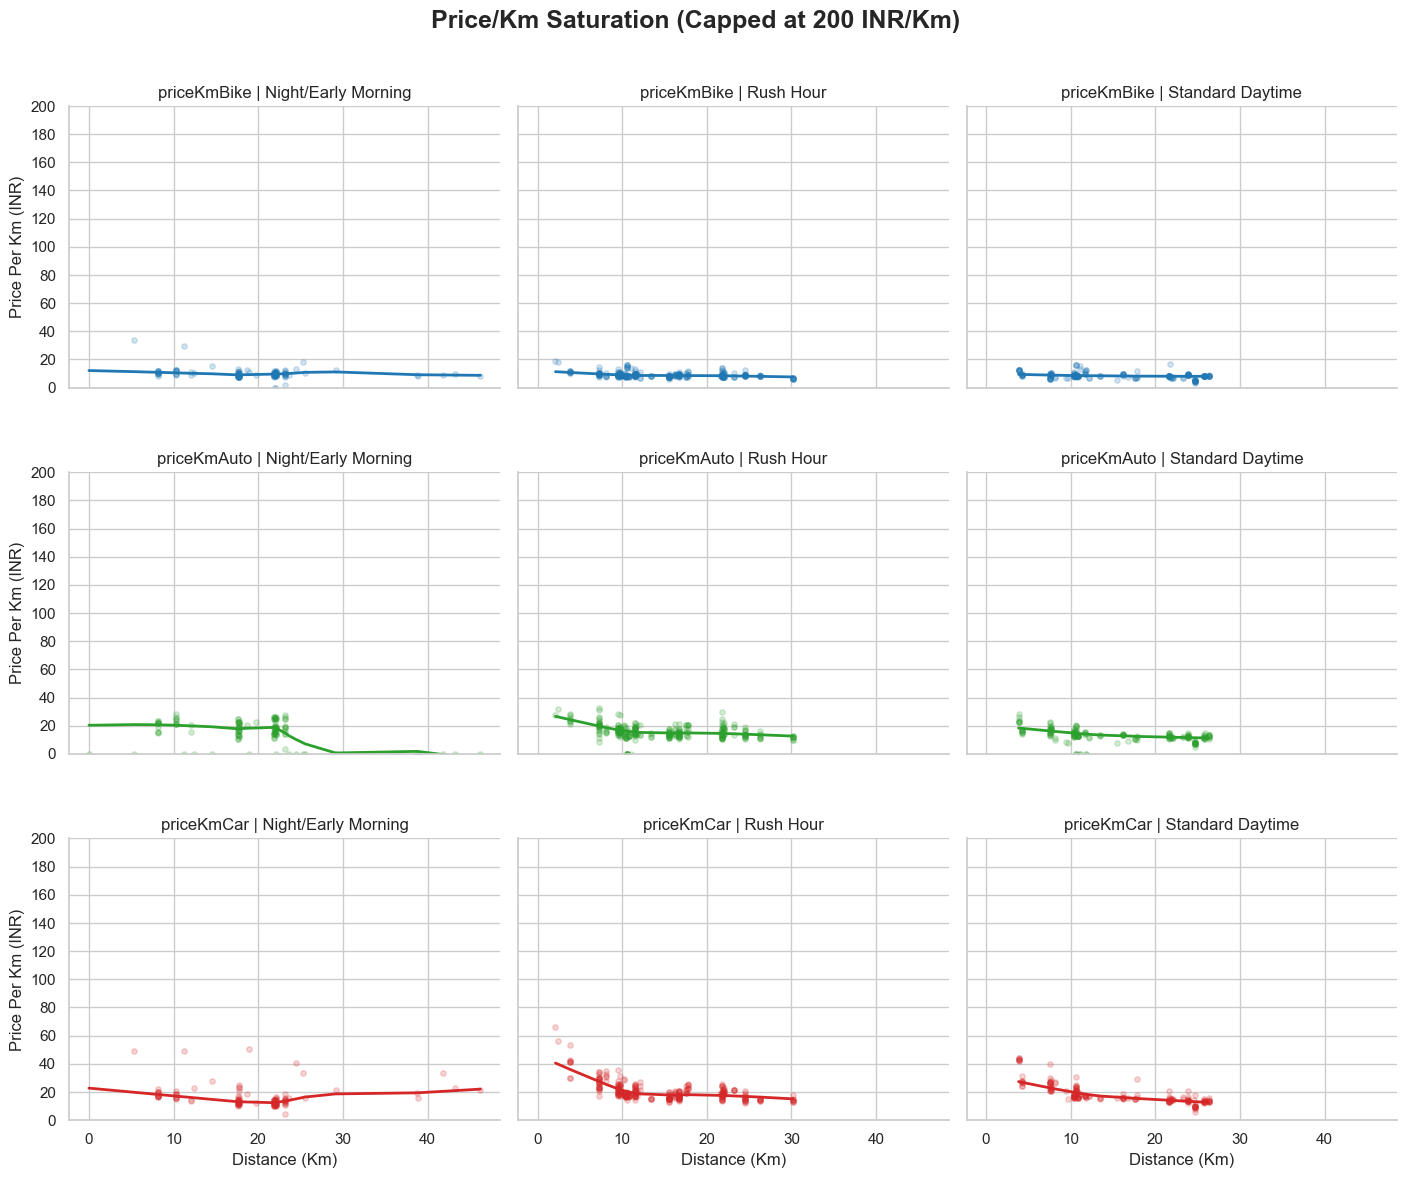

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Categorize Time of Day
def get_time_cat(row):
    rush_col = 'RushHour' if 'RushHour' in df.columns else 'Rushhour'
    if row[rush_col] == 1:
        return 'Rush Hour'
    elif 6 <= row['DecimalHour'] < 22:
        return 'Standard Daytime'
    else:
        return 'Night/Early Morning'

df['TimeCategory'] = df.apply(get_time_cat, axis=1)

# 3. Melt the dataframe
df_long = pd.melt(df, 
                  id_vars=['DistanceKm', 'TimeCategory'], 
                  value_vars=['priceKmBike', 'priceKmAuto', 'priceKmCar'],
                  var_name='VehicleType', value_name='PricePerKm')

# 4. Create the FacetGrid with SHAREY=True
g = sns.FacetGrid(df_long, col="TimeCategory", row="VehicleType", 
                  hue="VehicleType", 
                  palette={'priceKmBike': '#1f77b4', 
                           'priceKmAuto': '#2ca02c', 
                           'priceKmCar': '#d62728'},
                  sharey=True, 
                  height=4, aspect=1.2)

# 5. Map the Lowess plot
# Any data points above 200 will simply be 'clipped' out of view
g.map(sns.regplot, "DistanceKm", "PricePerKm", 
      lowess=True, scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'linewidth': 2})

# 6. ENFORCE 20-UNIT INTERVALS (CAP AT 200)
y_ticks = np.arange(0, 201, 20) # 0, 20, 40 ... 200

g.set(yticks=y_ticks) 
g.set(ylim=(0, 200)) # This physically locks the view to your requested range

# 7. Aesthetics
g.set_axis_labels("Distance (Km)", "Price Per Km (INR)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.subplots_adjust(top=0.9, hspace=0.3)
g.fig.suptitle('Price/Km Saturation (Capped at 200 INR/Km)', fontsize=18, fontweight='bold')

plt.show()

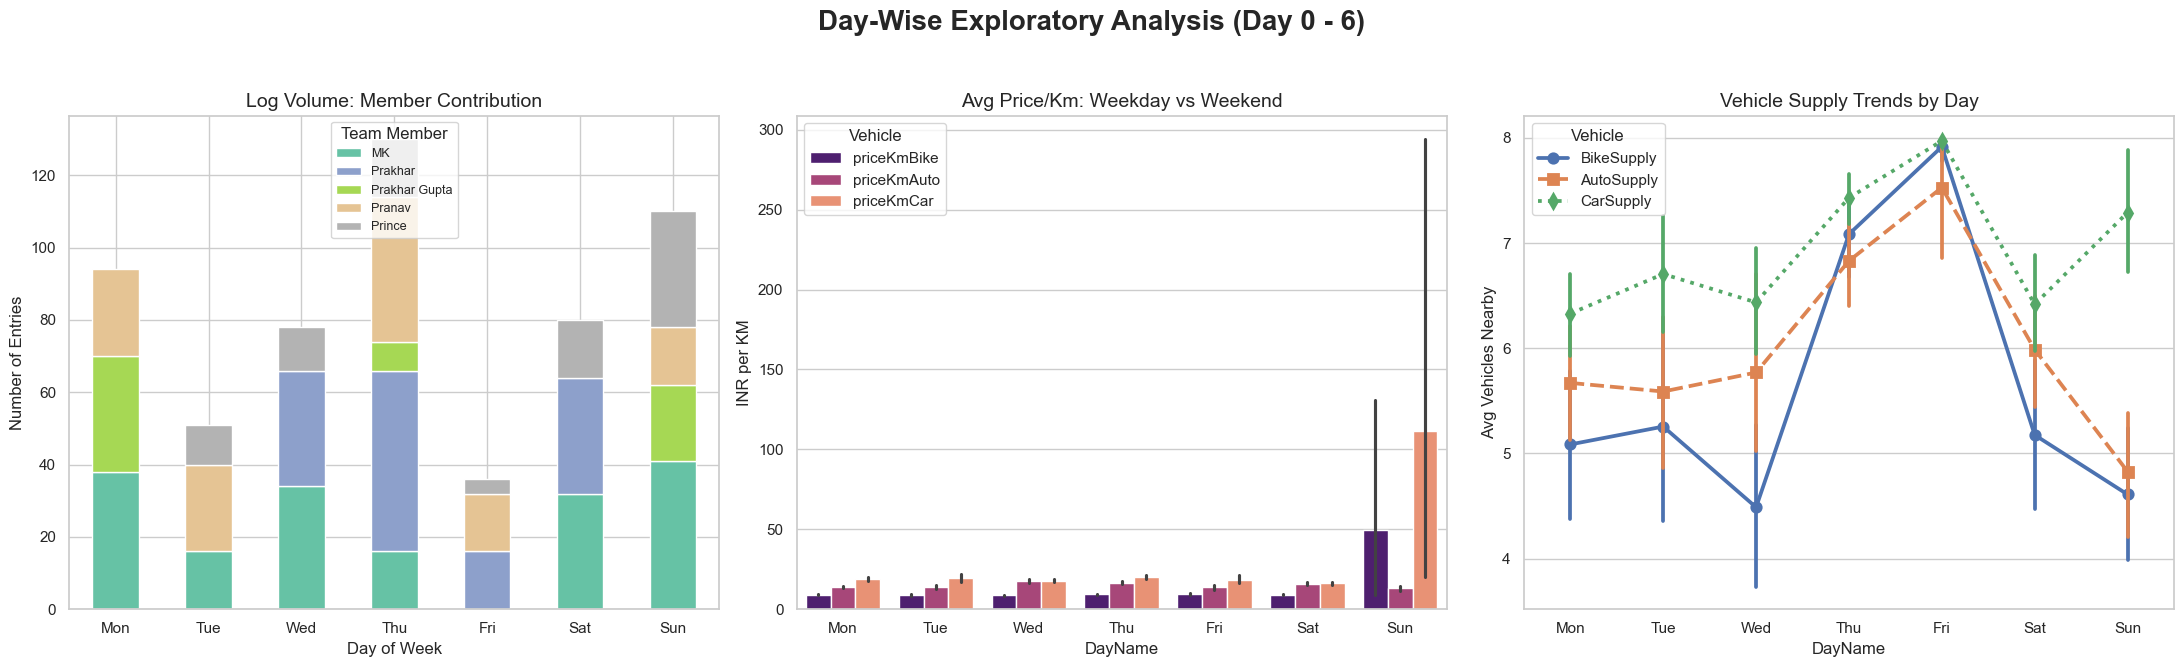

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Map Day numbers to Names for readability
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['DayName'] = df['Day'].map(day_map)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 3. Create a Dashboard: Volume, Price, and Supply
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Day-Wise Exploratory Analysis (Day 0 - 6)', fontsize=20, fontweight='bold')

# Convert supply columns to numeric, replacing invalid entries with NaN
for col in ['BikeSupply', 'AutoSupply', 'CarSupply']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- PLOT 1: Data Volume (Stacked by Member) ---
# We create a cross-tabulation of Day vs Name and plot it as a stacked bar
volume_pivot = pd.crosstab(df['DayName'], df['Your Name']).reindex(day_order)
volume_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')

axes[0].set_title('Log Volume: Member Contribution', fontsize=14)
axes[0].set_ylabel('Number of Entries')
axes[0].set_xlabel('Day of Week')
axes[0].legend(title='Team Member', fontsize=9, loc='upper center')
axes[0].tick_params(axis='x', rotation=0) # Keep day names horizontal

# --- PLOT 2: Average Price/Km per Day ---
price_df = pd.melt(df, id_vars=['DayName'], 
                   value_vars=['priceKmBike', 'priceKmAuto', 'priceKmCar'],
                   var_name='Vehicle', value_name='Price')

sns.barplot(data=price_df, x='DayName', y='Price', hue='Vehicle', 
            order=day_order, palette='magma', ax=axes[1])
axes[1].set_title('Avg Price/Km: Weekday vs Weekend', fontsize=14)
axes[1].set_ylabel('INR per KM')

# --- PLOT 3: Supply Availability per Day ---
# Ensure these column names match your CSV (case-sensitive)
supply_df = pd.melt(df, id_vars=['DayName'], 
                    value_vars=['BikeSupply', 'AutoSupply', 'CarSupply'],
                    var_name='Vehicle', value_name='Supply')

sns.pointplot(data=supply_df, x='DayName', y='Supply', hue='Vehicle', 
              order=day_order, markers=['o', 's', 'd'], linestyles=['-', '--', ':'], ax=axes[2])
axes[2].set_title('Vehicle Supply Trends by Day', fontsize=14)
axes[2].set_ylabel('Avg Vehicles Nearby')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

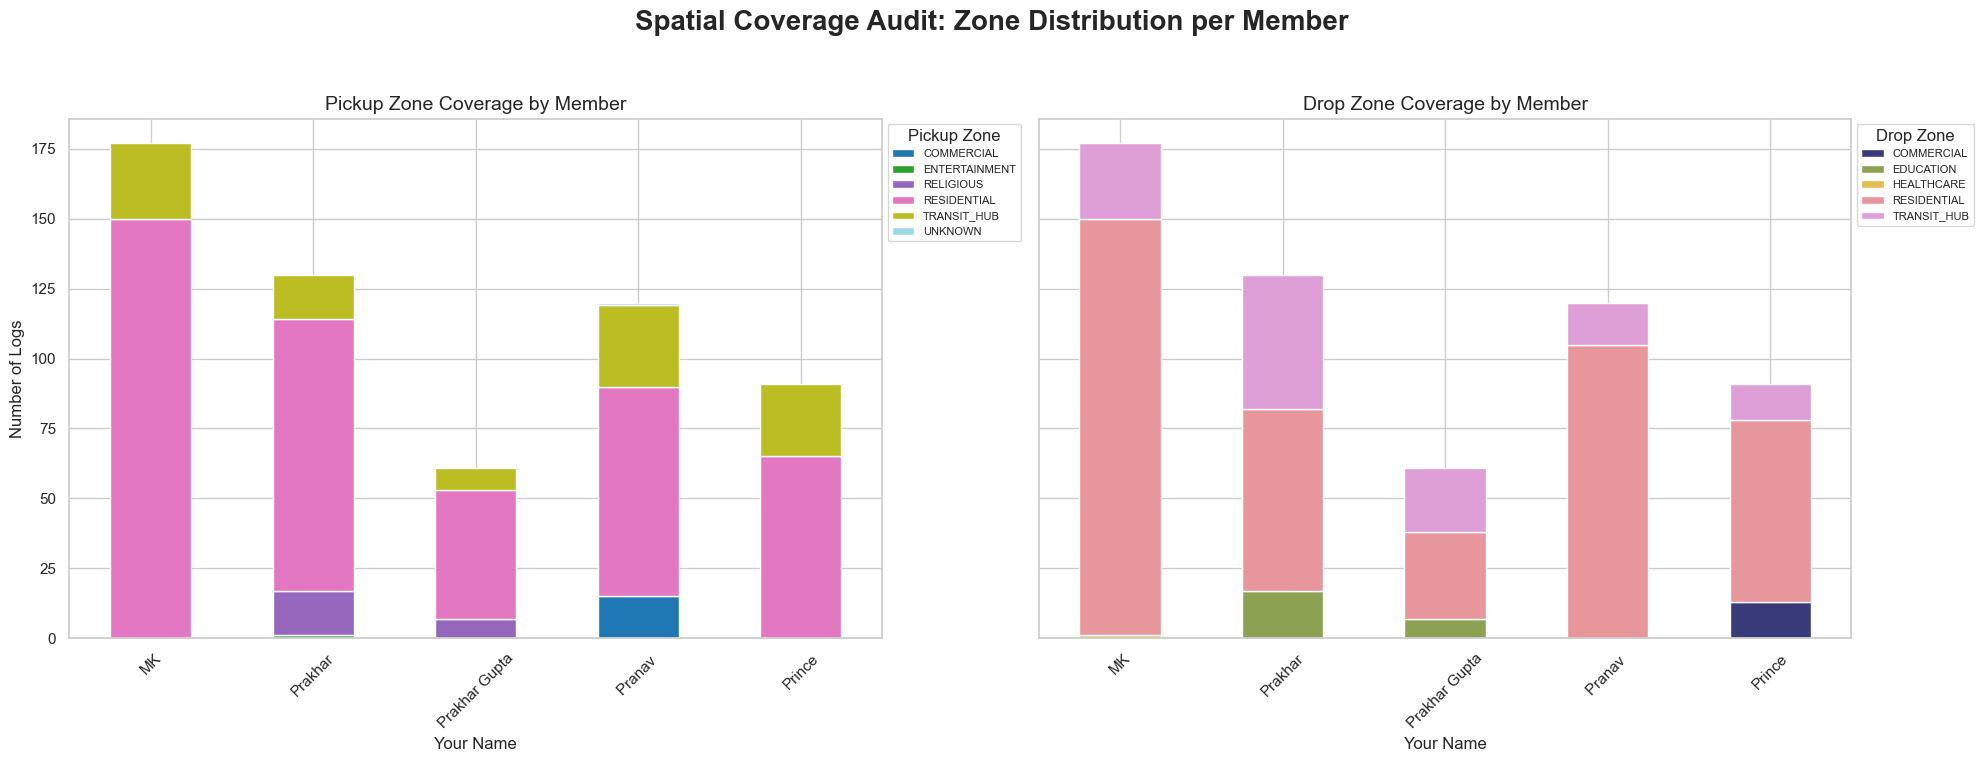

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Setup a 1x2 Subplot (Pickup Zones vs Drop Zones)
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
fig.suptitle('Spatial Coverage Audit: Zone Distribution per Member', fontsize=20, fontweight='bold')

# --- PLOT 1: Pickup Zone Distribution ---
# Pivot data: Rows = Names, Columns = Pickup Zones, Values = Count
pickup_pivot = pd.crosstab(df['Your Name'], df['PickupZone'])
pickup_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20', edgecolor='white')

axes[0].set_title('Pickup Zone Coverage by Member', fontsize=14)
axes[0].set_ylabel('Number of Logs')
axes[0].legend(title='Pickup Zone', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: Drop Zone Distribution ---
# Pivot data: Rows = Names, Columns = Drop Zones, Values = Count
drop_pivot = pd.crosstab(df['Your Name'], df['DropZone'])
drop_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20b', edgecolor='white')

axes[1].set_title('Drop Zone Coverage by Member', fontsize=14)
axes[1].legend(title='Drop Zone', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

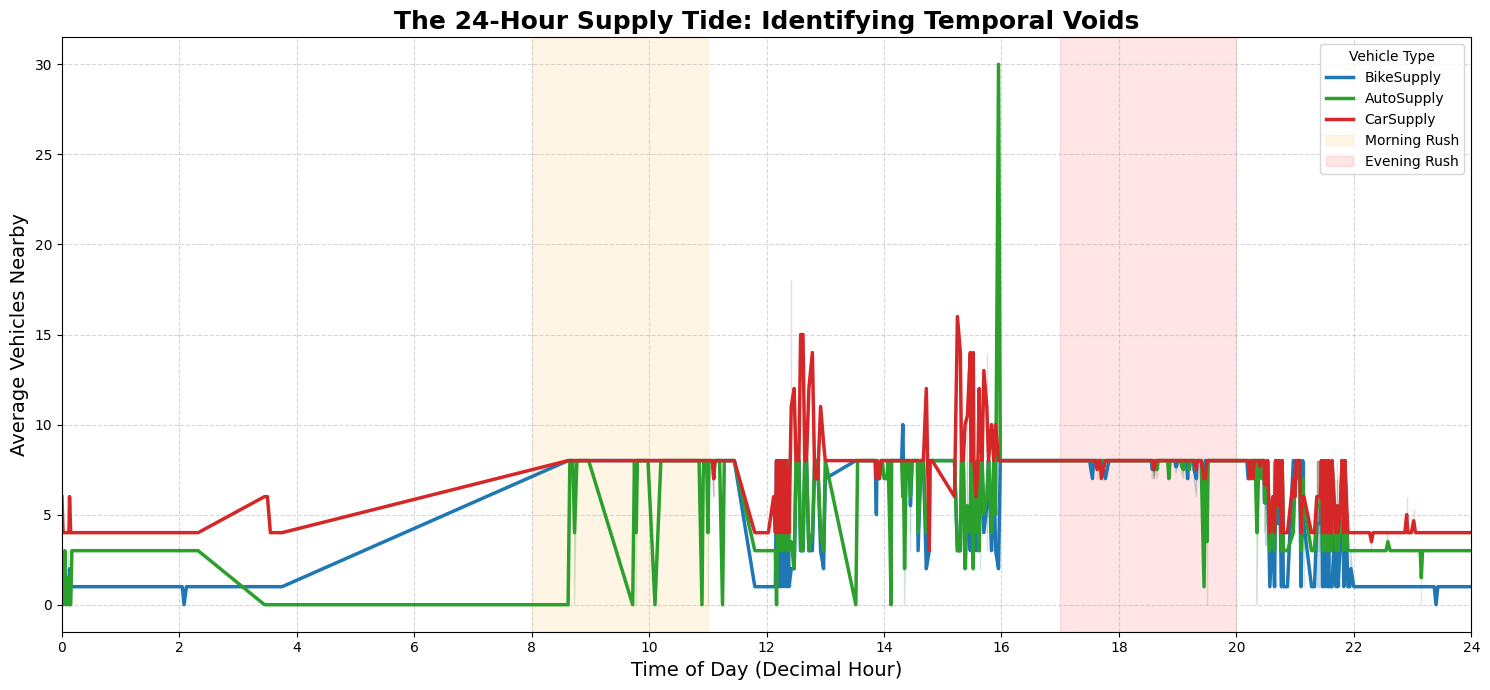

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Ride Data Responses.csv")

# 2. Pre-process: Ensure numeric values and handle NaNs
supply_cols = ['BikeSupply', 'AutoSupply', 'CarSupply']
for col in supply_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Melt the data to include DecimalHour
df_long = pd.melt(df, 
                  id_vars=['DecimalHour'], 
                  value_vars=supply_cols, 
                  var_name='VehicleType', value_name='SupplyCount')

# Drop missing values to keep the trend line clean
df_long = df_long.dropna()

# 4. Create the Supply Tide Plot
plt.figure(figsize=(15, 7))

# Using lineplot with a confidence interval (shaded area)
# This shows the "Average" supply at that decimal time
sns.lineplot(data=df_long, 
             x='DecimalHour', 
             y='SupplyCount', 
             hue='VehicleType', 
             palette={'BikeSupply': '#1f77b4', 'AutoSupply': '#2ca02c', 'CarSupply': '#d62728'},
             linewidth=2.5,
             errorbar=('ci', 68)) # Shows standard error for data density awareness

# 5. Aesthetics & Formatting
plt.title('The 24-Hour Supply Tide: Identifying Temporal Voids', fontsize=18, fontweight='bold')
plt.xlabel('Time of Day (Decimal Hour)', fontsize=14)
plt.ylabel('Average Vehicles Nearby', fontsize=14)

# Set X-axis ticks for every 2 hours for better readability
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight typical "Rush Hour" blocks for context
plt.axvspan(8, 11, color='orange', alpha=0.1, label='Morning Rush')
plt.axvspan(17, 20, color='red', alpha=0.1, label='Evening Rush')

plt.legend(title='Vehicle Type', loc='upper right')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pickle
import json

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv('Ride Data.csv')

# ==============================
# 2. SANITIZE DATA
# ==============================
numeric_cols = [
    'priceKmBike', 'priceKmAuto', 'priceKmCar',
    'BikeWait', 'AutoWait', 'CarWait',
    'PickupTemperature', 'PickupHumidity',
    'DropTemperature', 'DropHumidity',
    'PickupWindSpeed', 'DropWindSpeed',
    'DistanceKm', 'Duration', 'SurgeValue'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ==============================
# 3. CREATE AVAILABILITY LABELS
# ==============================
df['Bike_Available'] = (df['priceKmBike'] > 0).astype(int)
df['Auto_Available'] = (df['priceKmAuto'] > 0).astype(int)
df['Car_Available'] = (df['priceKmCar'] > 0).astype(int)

# ==============================
# 4. ENCODING
# ==============================

# Traffic
le_traffic = LabelEncoder()
df['TrafficLevel'] = df['TrafficLevel'].astype(str).str.upper()
df['Traffic_Enc'] = le_traffic.fit_transform(df['TrafficLevel'])
traffic_mapping = {str(k): int(v) for k, v in zip(le_traffic.classes_, le_traffic.transform(le_traffic.classes_))}

# Zones
le_zone = LabelEncoder()
all_zones = pd.concat([df['PickupZone'], df['DropZone']]).astype(str).str.upper().unique()
le_zone.fit(all_zones)

df['Pickup_Enc'] = le_zone.transform(df['PickupZone'].astype(str).str.upper())
df['Drop_Enc'] = le_zone.transform(df['DropZone'].astype(str).str.upper())

zone_mapping = {str(k): int(v) for k, v in zip(le_zone.classes_, le_zone.transform(le_zone.classes_))}

# 🔥 Platform Encoding (NEW)
le_platform = LabelEncoder()
df['Platform'] = df['Platform'].astype(str).str.upper()
df['Platform_Enc'] = le_platform.fit_transform(df['Platform'])

platform_mapping = {str(k): int(v) for k, v in zip(le_platform.classes_, le_platform.transform(le_platform.classes_))}

# Save mappings
with open('traffic_map.json', 'w') as f:
    json.dump(traffic_mapping, f)

with open('zone_map.json', 'w') as f:
    json.dump(zone_mapping, f)

with open('platform_map.json', 'w') as f:
    json.dump(platform_mapping, f)

# ==============================
# 5. FEATURE SET (FULL POWER)
# ==============================
features = [
    'DecimalHour', 'Day', 'Weekend', 'Rushhour',
    'DistanceKm', 'Duration',
    'Traffic_Enc', 'SurgeValue',
    
    # Weather (pickup)
    'PickupTemperature', 'PickupHumidity',
    'PickupWindSpeed', 'PickupWeatherCode',
    
    # Weather (drop)
    'DropTemperature', 'DropHumidity',
    'DropWindSpeed', 'DropWeatherCode',
    
    # Location
    'Pickup_Enc', 'Drop_Enc',
    
    # 🔥 PLATFORM
    'Platform_Enc'
]

vehicles = ['Bike', 'Auto', 'Car']

# ==============================
# 6. TRAIN MODELS
# ==============================

for v in vehicles:

    print(f"\nTraining models for {v}...")

    # ======================
    # A. CLASSIFIER
    # ======================
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(df[features], df[f'{v}_Available'])

    with open(f'clf_{v.lower()}.pkl', 'wb') as f:
        pickle.dump(clf, f)

    # ======================
    # B. PRICE MODEL
    # ======================
    reg_df = df[(df[f'priceKm{v}'] > 0) & (df[f'priceKm{v}'] < 500)].copy()

    reg = RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        random_state=42
    )

    reg.fit(reg_df[features], reg_df[f'priceKm{v}'])

    with open(f'reg_{v.lower()}.pkl', 'wb') as f:
        pickle.dump(reg, f)

    # ======================
    # C. WAIT MODEL
    # ======================
    wait_col = f'{v}Wait'

    wait_df = df[(df[wait_col] > 0) & (df[wait_col] < 120)].copy()

    wait_model = RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        random_state=42
    )

    wait_model.fit(wait_df[features], wait_df[wait_col])

    with open(f'wait_{v.lower()}.pkl', 'wb') as f:
        pickle.dump(wait_model, f)

print("\n🔥 SUCCESS: Platform-aware models trained!")


Training models for Bike...

Training models for Auto...

Training models for Car...

🔥 SUCCESS: Platform-aware models trained!


In [1]:
import pandas as pd
import numpy as np
import pickle
import json
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATA
df = pd.read_csv('Ride Data.csv')

# 2. DATA CLEANING & PREPROCESSING
# Use all numeric columns mentioned in the dataset
numeric_cols = [
    'Hour', 'Minute', 'DecimalHour', 'Day', 'Weekend', 'Rushhour', 
    'DistanceKm', 'Duration', 'SurgeValue', 
    'PickupTemperature', 'PickupWindSpeed', 'PickupWeatherCode', 'PickupHumidity',
    'DropTemperature', 'DropWindSpeed', 'DropWeatherCode', 'DropHumidity',
    'BikeWait', 'AutoWait', 'CarWait',
    'priceKmBike', 'priceKmAuto', 'priceKmCar'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Availability labels for the Classifier
df['Bike_Available'] = (df['priceKmBike'] > 0).astype(int)
df['Auto_Available'] = (df['priceKmAuto'] > 0).astype(int)
df['Car_Available'] = (df['priceKmCar'] > 0).astype(int)

# 3. CATEGORICAL ENCODING (Saving these for your Backend API)
cat_cols = ['Platform', 'TrafficLevel', 'PickupZone', 'DropZone']
mappings = {}
encoders = {}

for col in cat_cols:
    df[col] = df[col].astype(str).str.upper()
    if col in ['PickupZone', 'DropZone']:
        # Shared encoder for both zones to maintain consistent numeric mapping
        if 'ZoneEncoder' not in encoders:
            le_zone = LabelEncoder()
            all_zones = pd.concat([df['PickupZone'], df['DropZone']]).unique()
            le_zone.fit(all_zones)
            encoders['ZoneEncoder'] = le_zone
            mappings['zone_map'] = {str(k): int(v) for k, v in zip(le_zone.classes_, le_zone.transform(le_zone.classes_))}
        df[f'{col}_Enc'] = encoders['ZoneEncoder'].transform(df[col])
    else:
        le = LabelEncoder()
        df[f'{col}_Enc'] = le.fit_transform(df[col])
        mappings[f'{col.lower()}_map'] = {str(k): int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}

# Save mappings
for map_name, map_dict in mappings.items():
    with open(f'{map_name}.json', 'w') as f: json.dump(map_dict, f)

# 4. DEFINE THE FEATURE VECTOR (Every single attribute included)
features = [
    'Platform_Enc', 'Hour', 'Minute', 'DecimalHour', 'Day', 'Weekend', 'Rushhour', 
    'DistanceKm', 'Duration', 'TrafficLevel_Enc', 'SurgeValue', 
    'PickupTemperature', 'PickupWindSpeed', 'PickupWeatherCode', 'PickupHumidity',
    'DropTemperature', 'DropWindSpeed', 'DropWeatherCode', 'DropHumidity',
    'PickupZone_Enc', 'DropZone_Enc'
]

# 5. TRAIN AND SAVE ALL MODELS
vehicles = ['Bike', 'Auto', 'Car']

for v in vehicles:
    # A. Availability Classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(df[features], df[f'{v}_Available'])
    with open(f'clf_{v.lower()}.pkl', 'wb') as f: pickle.dump(clf, f)
    
    # B. Fare Regressor (Price per KM)
    reg_df = df[df[f'priceKm{v}'] > 0].copy()
    reg = RandomForestRegressor(n_estimators=100, random_state=42)
    reg.fit(reg_df[features], reg_df[f'priceKm{v}'])
    with open(f'reg_{v.lower()}.pkl', 'wb') as f: pickle.dump(reg, f)
    
    # C. Wait-Time Regressor
    wait_df = df[df[f'{v}Wait'] > 0].copy()
    w_reg = RandomForestRegressor(n_estimators=100, random_state=42)
    w_reg.fit(wait_df[features], wait_df[f'{v}Wait'])
    with open(f'wait_reg_{v.lower()}.pkl', 'wb') as f: pickle.dump(w_reg, f)

print("SUCCESS: 9 Models and JSON mappings generated using the full feature set.")

SUCCESS: 9 Models and JSON mappings generated using the full feature set.
